## Trabajo Práctico 1 - Tecnología Digital VI: Machine Learning
 
**Integrantes:** Lourdes Moreira, Juana Arslanian y Matías Cerdeira  

**Fecha de entrega:** 2 de septiembre de 2026

## Introducción

En este trabajo desarrollamos dos problemas de clasificación con el mismo conjunto de datos. La Parte I vamos a analizar el problema de abandono de clientes, conocido como *Customer Churn*, utilizando un dataset de una empresa de telecomunicaciones y poniendo el foco en la prevención de *data leakage*, la validación y las métricas de negocio. La Parte II reformula el objetivo para predecir si un cliente con servicio de internet contrataría o no servicio de *streaming*.

## Parte I

### 1. Problema y Análisis Exploratorio de los datos

Una empresa de telecomunicaciones quiere identificar clientes con riesgo de abandonar el servicio. Cada fila representa un cliente e incluye información sobre su antigüedad, los servicios que tiene contratados, el tipo de contrato, su forma de pago y sus cargos mensuales, entre otras variables. La variable que queremos predecir, es decir, el target `Churn` vale `Yes` cuando el cliente abandonó el servicio. 

Anticipar qué clientes tienen mayor probabilidad de irse permitiría dirigir acciones de retención, como ofrecer descuentos a tiempo. Sin embargo, el objetivo no es predecir muchos `No`, sino encontrar una proporción útil de las fugas sin enviar descuentos indiscriminadamente. Por eso más adelante contrastamos *precision* y *recall* y no evaluamos el modelo solo con *accuracy*.

De este modo, comenzamos cargando los datos y miramos las primeras 5 filas para ver qué variables incluye el dataset y obtener un panorama más claro a la hora de armar el modelo.

In [78]:
import pandas as pd

datos = pd.read_csv("dataset Telco Customer Churn.csv", na_values=[" "]) 
#aclaramos cómo tratar a los vacíos para que pandas pueda leer TotalCharges como columna númerica y no como texto
print("Filas:", datos.shape[0], "| Columnas:", datos.shape[1])


datos.head()

Filas: 7043 | Columnas: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Detectamos variables categóricas y numéricas, y consultamos ciertos features que hacen más fácil entender el dataset. Estos features son numéricos:
- `tenure`: Es la cantidad de meses que el cliente lleva en la empresa.
- `TotalCharges`: Es el total acumulado que se le cobró durante toda su relación con la empresa.
- `MonthlyCharges`: importe que se le cobra al cliente mensualmente.

Luego, chequeamos si hay alguna columna que contenga datos faltantes, cuál es y cuántos posee, ya que puede contener información útil que no esté siendo bien procesada.

In [109]:
faltantes = datos.isna().sum()

faltantes[faltantes > 0]

Series([], dtype: int64)

In [ ]:
casos_sin_total = datos.loc[
    datos["TotalCharges"].isna(),
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges"],
]
casos_sin_total

Asimismo, armamos un resumen de las variables para ver si hay datos duplicados e incluye estadísticas descriptivas. 

In [80]:
print("Filas duplicadas:", datos.duplicated().sum())
print("IDs duplicados:", datos["customerID"].duplicated().sum())

resumen_numerico = datos[["tenure", "MonthlyCharges", "TotalCharges"]].describe().T
columnas_categoricas = datos.select_dtypes(exclude="number").columns
resumen_categorico = pd.DataFrame({
    "categorías": datos[columnas_categoricas].nunique(),
    "moda": datos[columnas_categoricas].mode().iloc[0],
    "frecuencia_moda": [
        datos[columna].value_counts().iloc[0]
        for columna in columnas_categoricas
    ],
})

print("Resumen de variables numéricas")
display(resumen_numerico.round(2))
print("Resumen de variables categóricas")
display(resumen_categorico)

Filas duplicadas: 0
IDs duplicados: 0
Resumen de variables numéricas


,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.37,24.56,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.76,30.09,18.25,35.50,70.35,89.85,118.75
TotalCharges,7032.0,2283.30,2266.77,18.80,401.45,1397.48,3794.74,8684.80


Resumen de variables categóricas


,categorías,moda,frecuencia_moda
customerID,7043,0002-ORFBO,1
gender,2,Male,3555
Partner,2,No,3641
Dependents,2,No,4933
PhoneService,2,Yes,6361
MultipleLines,3,No,3390
InternetService,3,Fiber optic,3096
OnlineSecurity,3,No,3498
OnlineBackup,3,No,3088
DeviceProtection,3,No,3095


#### Visualizaciones relevantes

#### Grafico 1: Distribución de la variable Churn

Notamos un desbalance en la variable `Churn` el cual es relevante porque un modelo podría obtener un *accuracy* aparentemente alto simplemente prediciendo siempre la clase mayoritaria. Por este motivo, también será necesario considerar *Precision*, *Recall* y *F1-Score*.

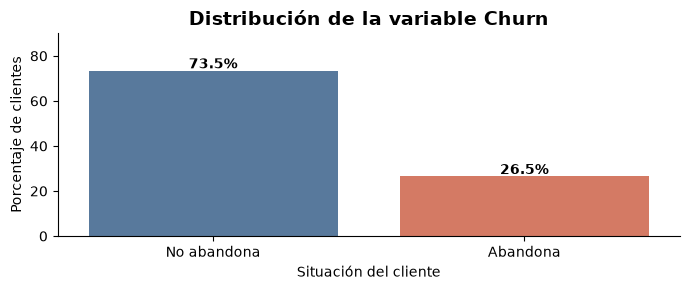

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns


porcentajes_churn = (
    datos["Churn"]
    .value_counts(normalize=True)
    .reindex(["No", "Yes"])
    .mul(100)
)

distribucion_churn = pd.DataFrame({
    "Situación": [
        "No abandona",
        "Abandona"
    ],
    "Porcentaje": porcentajes_churn.values
})

plt.figure(figsize=(7, 3))

ax = sns.barplot(
    data=distribucion_churn,
    x="Situación",
    y="Porcentaje",
    hue="Situación",
    palette={
        "No abandona": "#4C78A8",
        "Abandona": "#E76F51"
    },
    legend=False
)

for barra in ax.patches:
    porcentaje = barra.get_height()

    ax.text(
        barra.get_x() + barra.get_width() / 2,
        porcentaje + 1,
        f"{porcentaje:.1f}%",
        ha="center",
        fontweight="bold"
    )

ax.set_title(
    "Distribución de la variable Churn",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Situación del cliente")
ax.set_ylabel("Porcentaje de clientes")
ax.set_ylim(0, 90)

sns.despine()
plt.tight_layout()
plt.show()

El gráfico muestra que la variable objetivo se encuentra desbalanceada: aproximadamente el 73,5% de los clientes no abandona el servicio, mientras que solo el 26,5% presenta fuga.

#### Gráfico 2: Relación entre el tipo de contrato y el abandono

La variable `Contract` indica la duración del contrato del cliente. Puede tomar tres valores: **mensual** (Month-to-month), **anual** (One year) o de **dos años** (Two year).

Para analizar su relación con el abandono, calculamos el porcentaje de clientes con `Churn = Yes` dentro de cada tipo de contrato.

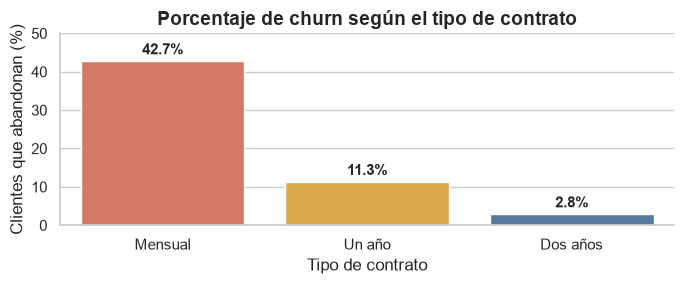

In [82]:
# Calculamos el porcentaje de churn para cada tipo de contrato
churn_por_contrato = (
    datos
    .assign(
        Churn_binario=(datos["Churn"] == "Yes").astype(int)
    )
    .groupby("Contract", as_index=False)["Churn_binario"]
    .mean()
)

churn_por_contrato["Porcentaje de churn"] = (
    churn_por_contrato["Churn_binario"] * 100
)

# Traducimos los nombres antes de construir el gráfico
traduccion_contratos = {
    "Month-to-month": "Mensual",
    "One year": "Un año",
    "Two year": "Dos años"
}

churn_por_contrato["Tipo de contrato"] = (
    churn_por_contrato["Contract"]
    .map(traduccion_contratos)
)

orden_contratos = [
    "Mensual",
    "Un año",
    "Dos años"
]

# Construimos el gráfico
sns.set_theme(style="whitegrid")

plt.figure(figsize=(7, 3))

ax = sns.barplot(
    data=churn_por_contrato,
    x="Tipo de contrato",
    y="Porcentaje de churn",
    order=orden_contratos,
    hue="Tipo de contrato",
    palette={
        "Mensual": "#E76F51",
        "Un año": "#F2B134",
        "Dos años": "#4C78A8"
    },
    legend=False
)

# Mostramos el porcentaje encima de cada barra
for barra in ax.patches:
    porcentaje = barra.get_height()

    ax.text(
        barra.get_x() + barra.get_width() / 2,
        porcentaje + 1,
        f"{porcentaje:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.set_title(
    "Porcentaje de churn según el tipo de contrato",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Tipo de contrato")
ax.set_ylabel("Clientes que abandonan (%)")
ax.set_ylim(0, 50)

sns.despine()
plt.tight_layout()
plt.show()

El gráfico muestra una relación clara entre la duración del contrato y la probabilidad de abandono. Aproximadamente el 42,7% de los clientes con contrato mensual abandona el servicio, mientras que este porcentaje disminuye al 11,3% entre quienes tienen contratos de un año y al 2,8% entre quienes poseen contratos de dos años.

Esto sugiere que los clientes con contratos de mayor duración presentan una relación más estable con la empresa. En cambio, quienes tienen contratos mensuales pueden cancelar con mayor facilidad y constituyen el grupo con mayor riesgo de churn. Por lo tanto, `Contract` podría ser una variable relevante para predecir el abandono.

#### Gráfico 3: Relación entre los cargos mensuales y el abandono

La variable `MonthlyCharges` representa el importe mensual que paga cada cliente. Para analizar su relación con el abandono, comparamos la distribución de los cargos mensuales entre quienes permanecieron en la empresa y quienes abandonaron el servicio.


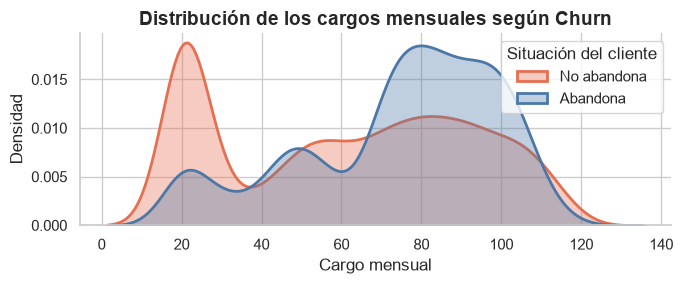

In [83]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(7, 3))

sns.kdeplot(
    data=datos[datos["Churn"] == "No"],
    x="MonthlyCharges",
    fill=True,
    color="#E76F51",
    alpha=0.35,
    linewidth=2,
    label="No abandona"
)

sns.kdeplot(
    data=datos[datos["Churn"] == "Yes"],
    x="MonthlyCharges",
    fill=True,
    color="#4C78A8",
    alpha=0.35,
    linewidth=2,
    label="Abandona"
)

plt.title(
    "Distribución de los cargos mensuales según Churn",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Cargo mensual")
plt.ylabel("Densidad")
plt.legend(title="Situación del cliente")

sns.despine()
plt.tight_layout()
plt.show()

El gráfico muestra que los clientes que abandonaron el servicio presentan una mayor concentración en los cargos mensuales elevados, especialmente alrededor de los 70 a 100. En cambio, entre quienes no abandonaron aparece una concentración importante de clientes con cargos mensuales bajos, cercanos a 20.

En promedio, los clientes que abandonaron pagaban aproximadamente 74,44 por mes, mientras que quienes permanecieron pagaban alrededor de 61,27. Esto indica que existe una asociación entre cargos mensuales más elevados y una mayor presencia de churn, por lo que ``MonthlyCharges`` podría ser una variable relevante para el modelo.

Sin embargo, el gráfico muestra una asociación y no permite afirmar que un cargo mensual elevado sea, por sí solo, la causa del abandono.

### Anomalía de `TotalCharges` y estrategia de faltantes

`TotalCharges` debería ser numérica, pero pandas la carga como texto porque contiene 11 valores formados solo por espacios. Sin embargo, al cargar el archivo indicamos que los espacios deben interpretarse como `NaN`, lo que permite que pandas reconozca la columna como numérica. Los 11 casos tienen `tenure = 0` por lo que son cuentas recién iniciadas, sin cargos acumulados. Por eso, nos pareció razonable asignarles `TotalCharges = 0` y no imputarle la mediana global porque introduciría un acumulado ficticio muy alto.

In [ ]:
datos["TotalCharges"] = datos["TotalCharges"].fillna(0)

#verificamos
print("Cantidad de datos faltantes en todo el dataset:", datos.isna().sum().sum())

Cantidad de datos faltantes en todo el dataset: 0


#### Escalado

### 2. Preprocesamiento y prevención de Data Leakage

El **data leakage** ocurre cuando el entrenamiento utiliza, directa o indirectamente, información que solo debería estar disponible al evaluar el modelo. Esto produce métricas demasiado optimistas y un desempeño que no se sostiene frente a datos nuevos.

Primero podemos aplicar correcciones determinísticas que no aprenden parámetros del conjunto de datos, como convertir tipos o completar un valor mediante una regla de negocio justificada. Después separamos los conjuntos de entrenamiento y test. A partir de ese momento, cualquier transformación que deba aprender estadísticas o categorías —por ejemplo, imputación por media o mediana, escalado y codificación— se ajusta únicamente con los datos de entrenamiento.

El uso de un `Pipeline` mantiene este orden también durante la validación cruzada: en cada partición, el preprocesamiento se ajusta exclusivamente con el subconjunto de entrenamiento correspondiente y luego se aplica al de validación.


___
Colocamos el escalado y la transformación de variables categóricas dentro de un pipeline. De esta manera, durante la validación cruzada, el preprocesamiento se ajusta únicamente con los folds utilizados para entrenar y luego se aplica al fold de validación. Finalmente, al entrenar el modelo completo, el procesamiento se ajusta con todo el conjunto de entrenamiento y se aplica al test sin volver a calcular sus parámetros. Esto evita que la información de validación o test influya en el entrenamiento.

Ahora separamos las features del target y organizamos donde: 
- `X` contiene las features utilizadas para predecir,
- `y` contiene lo que queremos predecir.

Excluimos `customerID` porque es único por persona y sirve sólo de identificador por lo que no contiene una señal generalizable y permitirlo como predictor agregaría miles de categorías sin significado. También, convertimos `Churn` en 0 y 1 para que después sea más fácil calcular las métricas, en vez de `Yes`, `No`.

In [86]:
from sklearn.model_selection import train_test_split

X = datos.drop(columns=["customerID", "Churn"])

y = datos["Churn"].map({
    "No": 0,
    "Yes": 1
})

Luego, dividimos el dataset en conjunto de entrenamiento y evaluación, en el que el 80% corresponde a Train y el 20% a Test, usamos una semilla fija = 42 para que la división sea siempre la misma pues sino cada ejecución puede producir un train y un test diferentes, y con la ayuda de `stratify=y` train y test conservan aproximadamente la distribución del dataset completo para que una división por casualidad tenga más o menos clientes que abandonan.

In [87]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

#### Importante aclaración:

Nosotros simplemente limpiamos el dataset al corregir los espacios vacíos con 0, puesto que los valores faltantes correspondían a clientes con antigüedad igual a cero, por lo que se completaron directamente con cero ya que no utiliza información del conjunto de test, así que no genera data leakage. Como no utilizamos una estadística calculada sobre todo el dataset podíamos hacerlo antes del Train/Test Split. Sin embargo, si hubiéramos utilizado una media o mediana, habría sido necesario calcularla utilizando solamente el conjunto de entrenamiento, ya que sino el promedio incluiría también a los clientes que después quedarían en test.

#### Armado del modelo

Utilizamos una regresión logística porque `Churn` es una variable binaria, donde cada cliente pertenece a la clase que abandona o a la que no abandona.

Con `OneHotEncoder`, separamos variables numéricas y categóricas porque `LogisticRegression` no puede trabajar directamente con textos y para no inventar un orden entre las categorías. Tras haber analizado el dataset, sabemos cuáles son las numéricas para discriminarlas y tratar todas las otras como categóricas. Asimismo, escalamos las numéricas para colocarlas en escalas comparables con `StandardScaler`. Esto es conveniente para una regresión logística porque utiliza regularización.

Tanto la transformación de las categorías como el escalado se colocan dentro de un pipeline. De esta manera se ajustan únicamente con los datos de entrenamiento. Si calculáramos el escalado con todo el dataset antes del split, estaríamos incorporando información del conjunto de test, lo que produciría data leakage.

In [88]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

variables_numericas = ["tenure", "MonthlyCharges", "TotalCharges"]

variables_categoricas = [
    columna
    for columna in X.columns
    if columna not in variables_numericas
]

preprocesador = ColumnTransformer(
    transformers=[
        (
            "numericas",
            StandardScaler(),
            variables_numericas
        ),
        (
            "categoricas",
            OneHotEncoder(handle_unknown="ignore"),
            variables_categoricas
        )
    ]
)
modelo = Pipeline(
    steps=[
        ("preprocesamiento", preprocesador),
        (
            "regresion_logistica",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

### 3. Estrategia de validación

Como una partición *holdout* evalúa el modelo una sola vez, el resultado puede depender de qué clientes cayeron por casualidad en validación (o evaluación). Para evitar esto, una validación cruzada *K-Fold* con K = 5 folds sobre el conjunto de entrenamiento, permite que en cada iteración el modelo se entrene con cuatro folds y se valide con el restante. El proceso se repite hasta que cada fold haya sido utilizado una vez para validación y así cada parte del conjunto de entrenamiento se utiliza una vez para validar.

Esta estrategia permite obtener cinco mediciones diferentes en lugar de depender de una única partición *holdout*. De esta manera, podemos calcular un desempeño promedio y observar la variación de las métricas entre los cinco folds.

In [89]:
from sklearn.model_selection import KFold, cross_validate

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
resultados = cross_validate(
    modelo,
    X_train,
    y_train,
    cv=kfold,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1"
    ]
)
resultados_cv = pd.DataFrame({
    "Accuracy": resultados["test_accuracy"],
    "Precision": resultados["test_precision"],
    "Recall": resultados["test_recall"],
    "F1": resultados["test_f1"]
})

resultados_cv.round(3)

,Accuracy,Precision,Recall,F1
0,0.802,0.633,0.538,0.582
1,0.821,0.645,0.589,0.616
2,0.800,0.697,0.525,0.599
3,0.807,0.659,0.578,0.616
4,0.787,0.641,0.518,0.573


In [90]:
resultados_cv.mean().round(3)

Accuracy     0.804
Precision    0.655
Recall       0.550
F1           0.597
dtype: float64

Cada fila de la tabla corresponde a una partición distinta de la validación cruzada y vemos que los resultados son relativamente similares entre las cinco particiones: el *accuracy* promedio es aproximadamente 0,804, la *precision* 0,655, el *Recall* 0,550 y el *F1-Score* 0,597. Esto indica que la estimación del desempeño es razonablemente estable y no queda determinada por una única partición de entrenamiento y validación.

El conjunto de test queda guardado para la evaluación final.
En cada vuelta se entrena el pipeline completo:
1. Se ajusta el escalado con cuatro folds.
2. Se aprende el One-Hot Encoding con cuatro folds.
3. Se entrena la regresión logística.
4. Se evalúa con el fold restante.

La validación cruzada se realiza únicamente sobre el conjunto de entrenamiento. El conjunto de test permanece separado y se utilizará una sola vez para evaluar el modelo final. Además, incluimos el escalado y la codificación dentro del pipeline para evitar que aprendan información del fold utilizado para validación.

#### Stratified K-Fold

Creemos que usar **Stratified K-Fold** sería conveniente ya que el problema del **K-Fold** común es que no garantiza que cada fold tenga la misma proporción de clientes que abandonan. Entonces para un conjunto de datos **desbalanceados** como este, donde aproximadamente el 73% no abandona y el 27% sí, resulta buena estrategia utilizar `StratifiedKFold` que intenta mantener esa proporción en cada fold, haciendo que las evaluaciones sean más comparables.

Para comprobar si la estratificación produce resultados diferentes, repetimos la validación cruzada utilizando StratifiedKFold.

In [91]:
from sklearn.model_selection import StratifiedKFold, cross_validate

stratified_kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

resultados_stratified = cross_validate(
    modelo,
    X_train,
    y_train,
    cv=stratified_kfold,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1"
    ]
)

resultados_cv_stratified = pd.DataFrame({
    "Accuracy": resultados_stratified["test_accuracy"],
    "Precision": resultados_stratified["test_precision"],
    "Recall": resultados_stratified["test_recall"],
    "F1": resultados_stratified["test_f1"]
})

resultados_cv_stratified.round(3)



,Accuracy,Precision,Recall,F1
0,0.799,0.645,0.535,0.585
1,0.782,0.607,0.502,0.549
2,0.803,0.660,0.532,0.589
3,0.816,0.664,0.622,0.642
4,0.810,0.684,0.528,0.596


In [92]:
resultados_cv_stratified.mean().round(3)

Accuracy     0.802
Precision    0.652
Recall       0.544
F1           0.592
dtype: float64

Los resultados de StratifiedKFold muestran un Accuracy promedio de aproximadamente 0,802, una Precision de 0,652, un Recall de 0,544 y un F1-Score de 0,592.

Estos resultados son muy similares a los obtenidos previamente con KFold, cuyos promedios fueron aproximadamente 0,803 de Accuracy, 0,655 de Precision, 0,550 de Recall y 0,597 de F1-Score. Por lo tanto, en este caso no se observa una diferencia importante en el desempeño promedio entre ambos métodos.

Sin embargo, consideramos que StratifiedKFold es la estrategia de validación más apropiada 


StratifiedKFold porque la variable objetivo está desbalanceada. A diferencia de KFold, este método conserva aproximadamente la proporción de clientes que abandonan y no abandonan en cada partición. Esto permite que cada fold sea más representativo del conjunto de datos y que las métricas obtenidas sean más confiables.

### 4. Evaluación del modelo base

Las validaciones cruzadas anteriores se utilizaron para evaluar el modelo y comparar las estrategias K-Fold y Stratified K-Fold. Durante ese proceso se entrenaron copias temporales del pipeline, pero todavía no se construyó el modelo final.
Ahora entrenamos una nueva versión del pipeline utilizando todo el conjunto de entrenamiento disponible. Luego usamos este modelo para realizar las predicciones sobre test, que se mantuvo separado durante todo el proceso.

In [93]:
modelo.fit(X_train, y_train);

predicciones = modelo.predict(X_test)

Calculamos métricas para ver qué tan bueno resultó el modelo y las organizamos en una tabla.

In [94]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
accuracy = accuracy_score(y_test, predicciones)
precision = precision_score(y_test, predicciones)
recall = recall_score(y_test, predicciones)
f1 = f1_score(y_test, predicciones)
metricas = pd.DataFrame({
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1-Score": [f1]
})

metricas.round(3)

,Accuracy,Precision,Recall,F1-Score
0,0.806,0.657,0.559,0.604


#### ¿Qué representa cada métrica?

- **Accuracy** es el porcentaje total de predicciones correctas
- **Precision** se fija de todos los clientes que el modelo señaló como posibles fugas, indica qué porcentaje realmente abandonó. En este caso, con precision de 0.657 significa que alrededor del 66% de los clientes señalados por el modelo efectivamente abandonó.
- **Recall** mira de todos los clientes que realmente abandonaron, indica qué porcentaje logró detectar el modelo. Acá el recall de 0.559 significa que el modelo detectó cerca del 56% de las fugas reales.
- **F1-Score** combina precision y recall en una sola métrica. Es útil cuando queremos considerar ambos tipos de error.

#### Matriz de confusión

Ahora calculamos la matriz de confusión en la que se incluyen los éxitos, fracaso, falsos positivos y falsos negativos.

In [95]:
from sklearn.metrics import confusion_matrix

matriz = confusion_matrix(y_test, predicciones)
matriz_confusion = pd.DataFrame(
    matriz,
    index=["Real: No abandona", "Real: Abandona"],
    columns=["Predice: No abandona", "Predice: Abandona"]
)

matriz_confusion

,Predice: No abandona,Predice: Abandona
Real: No abandona,926,109
Real: Abandona,165,209


En la visualización del Gráfico 2 observamos que la clase mayoritaria es `Churn = 0` 

dentro del conjunto de test, 1035 clientes no abandonaron el servicio y 374 sí lo hicieron. Esto representa aproximadamente un 73,5% de clientes con `Churn = 0` y un 26,5% con `Churn = 1`.

#### Modelo naive

Un modelo *naive* que predice la clase mayoritaria tendría un **accuracy** del 73,5% el cual parece muy alto pero es solamente porque la mayoría de los clientes no abandona. Como el accuracy se calcula haciendo:
$$
\frac{Predicciones~correctas}{Total~de~casos}
$$
acertaría siempre que sea `Churn = 0`.

Sin embargo, este modelo no detectaría ningún cliente que abandona por ende su **recall** para la clase positiva sería 0 pues siempre predice `No`.

Esto muestra que la **accuracy** puede resultar engañosa cuando las clases están desbalanceadas y que debe complementarse con métricas como *precision*, *recall* y *F1-Score*. En este caso, *precision* indica qué proporción de los descuentos enviados llega realmente a personas que se iban, *recall* indica qué proporción de las fugas logramos contactar y *F1-score* resume el equilibrio entre ambas. De este modo, *accuracy* es una buena métrica pero no sirve como única métrica.

### 5. Análisis de Negocio e Impacto de las Métricas

Creamos un segundo modelo aplicando la técnica de **Random Oversampling** sobre el conjunto de entrenamiento para lidiar con el desbalanceo de clases. En este caso, tenemos 4139 clientes que no abandonan y 1495 que sí. Para ello, creamos una tabla de entrenamiento que incluya el target y copiamos los datos de X y completamos a la clase minoritaria para que tenga la misma cantidad de observaciones, luego de hacer el Train/Test Split, porque si lo hiciéramos antes un mismo cliente podría terminar repetido tanto en train como en test, lo que sería *data leakage*. Por ende, no estamos creando clientes completamente nuevos sino repitiendo aleatoriamente observaciones de clientes que sí abandonaron. El conjunto de test no se modifica ya que debe conservar la distribución original para representar una evaluación realista.

La desventaja es que el oversampling repite observaciones existentes y puede aumentar el riesgo de sobreajuste, pero por ejemplo hacer **Undersampling** descartaría casi la mitad de la información de entrenamiento. De todas formas, resulta una técnica sencilla y adecuada para analizar cómo cambia el comportamiento del modelo cuando ambas clases tienen el mismo peso durante el entrenamiento.

In [98]:
y_train.value_counts()

Churn
0    4139
1    1495
Name: count, dtype: int64

In [99]:
from sklearn.utils import resample
from sklearn.base import clone

entrenamiento = X_train.copy()

entrenamiento["Churn"] = y_train

clase_mayoritaria = entrenamiento[
    entrenamiento["Churn"] == 0
]

clase_minoritaria = entrenamiento[
    entrenamiento["Churn"] == 1
]
clase_minoritaria_ampliada = resample(
    clase_minoritaria,
    replace=True,
    n_samples=len(clase_mayoritaria),
    random_state=42
)
entrenamiento_over = pd.concat([
    clase_mayoritaria,
    clase_minoritaria_ampliada
])
#para duplicar filas completas las habíamos unido pero las volvemos a separar para entrenar luego
X_train_over = entrenamiento_over.drop(
    columns="Churn"
)
y_train_over = entrenamiento_over["Churn"]
#verificamos el nuevo balance
y_train_over.value_counts()

Churn
0    4139
1    4139
Name: count, dtype: int64

Ahora que ambas clases tienen la misma cantidad de observaciones, creamos el nuevo modelo, lo entrenamos y evaluamos.

In [100]:
modelo_oversampling = clone(modelo)

modelo_oversampling.fit(
    X_train_over,
    y_train_over
);
predicciones_over = modelo_oversampling.predict(
    X_test
)

#### Métricas nuevas y comparación

Calculamos las métricas y comparamos con el modelo base.

In [101]:
accuracy_over = accuracy_score(
    y_test,
    predicciones_over
)

precision_over = precision_score(
    y_test,
    predicciones_over
)

recall_over = recall_score(
    y_test,
    predicciones_over
)

f1_over = f1_score(
    y_test,
    predicciones_over
)

comparacion_modelos = pd.DataFrame({
    "Modelo": [
        "Modelo base",
        "Modelo con oversampling"
    ],
    "Accuracy": [
        accuracy,
        accuracy_over
    ],
    "Precision": [
        precision,
        precision_over
    ],
    "Recall": [
        recall,
        recall_over
    ],
    "F1-Score": [
        f1,
        f1_over
    ]
})

comparacion_modelos.round(3)

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Modelo base,0.806,0.657,0.559,0.604
1,Modelo con oversampling,0.733,0.498,0.781,0.608


Construimos la matriz de confusión

In [102]:
matriz_over = confusion_matrix(
    y_test,
    predicciones_over
)

matriz_over_df = pd.DataFrame(
    matriz_over,
    index=[
        "Real: No abandona",
        "Real: Abandona"
    ],
    columns=[
        "Predice: No abandona",
        "Predice: Abandona"
    ]
)

matriz_over_df

,Predice: No abandona,Predice: Abandona
Real: No abandona,741,294
Real: Abandona,82,292


Observamos que el **Oversampling**:
- Reduce los falsos negativos de 165 a 82.
- Aumenta los verdaderos positivos de 209 a 292.
- Detecta 83 fugas adicionales.
- Aumenta los falsos positivos de 109 a 294.
- Genera 185 falsos positivos adicionales.
Esto explica por qué aumenta el *recall* pero disminuyen *precision* y *accuracy*.

El oversampling permite encontrar más clientes que realmente abandonan, pero también genera más falsas alarmas.

#### Interpretación de un falso positivo
Aunque en ciertos problemas es preferible tener más falsas alarmas que tildar positivos como negativos, en este 
caso, un falso positivo es un cliente que el modelo identifica como posible fuga, pero que en realidad no iba a abandonar, por lo que la empresa le ofrecería un descuento innecesario del 50% durante tres meses y perdería parte de la facturación que habría recibido de todas formas.

#### Interpretación de un falso negativo
Un falso negativo es un cliente que realmente abandona, pero que el modelo no identifica. La empresa pierde la oportunidad de ofrecerle una acción de retención y puede perder los ingresos futuros asociados con ese cliente.

#### Si el descuento es muy costoso
Si el descuento fuera muy costoso, intentaríamos maximizar *precision* para evitar ofrecerlo a demasiados clientes que no iban a abandonar. El modelo base tiene una *precision* aproximada de 0,657 y genera 109 falsos positivos, mientras que el modelo con **oversampling** tiene una *precision* cercana a 0,498 y genera 294 falsos positivos. Por ende, en este escenario sería preferible el modelo base.

#### Si el descuento es casi gratuito
Si el descuento fuera casi gratuito, intentaríamos maximizar *recall* para detectar la mayor cantidad posible de fugas. El modelo con **oversampling** alcanza un *recall* aproximado de 0,781 y reduce los falsos negativos de 165 a 82. De esta manera, aquí sería preferible el modelo con **oversampling** porque aunque contacte a más clientes que finalmente no iban a abandonar el descuento no representaría una pérdida para la empresa. 

# Parte II: Reformulando el Problema

Existen variables que al negocio no le interesaría predecir porque ya las conoce o porque como `tenure` y `TotalCharges` se conocen después de que el cliente ya eligió su contrato.

De este modo, elegimos predecir `StreamingMovies` dado que al negocio podría serle útil para hacer una campaña de cross-selling, es decir, ofrecer el servicio de películas a clientes de internet que todavía no lo tienen.

Como sus campos son `Yes`, `No`, `No internet service`, aquellos que no tienen servicio contratado no pueden contratar streaming, por eso es necesario excluirlos ya que no tendría sentido que el modelo aprenda que alguien sin internet no tiene streaming, porque sería una predicción demasiado obvia.

Transformamos el target en una variable binaria: asignamos `1` a los clientes que tienen StreamingMovies y `0` a quienes tienen internet, pero no contrataron el servicio.

Eliminamos las variables que no sirven y aquellas que podrían revelar indirectamente la respuesta como `MonthlyCharges` y `TotalCharges`, y dejamos variables que pueden describir el perfil del cliente sin contener directamente el precio del target. Claramente excluimos `StreamingMovies` porque sino habría *data leakage* pues el modelo recibiría la respuesta que queremos predecir.

In [ ]:
#excluimos clientes sin internet porque no pueden contratar StreamingMovies
datos_streaming = datos[
    datos["InternetService"] != "No"
].copy()

#nuevo target: 1 tiene StreamingMovies, 0 no tiene
y_streaming = (
    datos_streaming["StreamingMovies"] == "Yes"
).astype(int)

#features del nuevo problema sacando los que no van
X_streaming = datos_streaming.drop(
    columns=[
        "customerID",
        "Churn",
        "StreamingMovies",
        "MonthlyCharges",
        "TotalCharges"
    ]
)

#nueva división de entrenamiento y test
Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_streaming,
    y_streaming,
    test_size=0.20,
    random_state=42,
    stratify=y_streaming
)

Creamos un train y un test nuevos porque ahora utilizamos un target diferente. La nueva variable objetivo está prácticamente balanceada: la clase mayoritaria representa aproximadamente el 50,5% de las observaciones.

Separamos variables categoricas y numericas pero como eliminamos los cargos, la única variable verdaderamente numérica es `tenure`, por lo que las demás son todas categóricas. 
También, realizamos el preprocesamiento como ya habíamos hecho antes donde escalamos `tenure` y convertimos las variables de texto en columnas numéricas.

In [104]:
numericas_streaming = [
    "tenure"
]
categoricas_streaming = [
    columna
    for columna in X_streaming.columns
    if columna not in numericas_streaming
]

preprocesador_streaming = ColumnTransformer(
    transformers=[
        (
            "numericas",
            StandardScaler(),
            numericas_streaming
        ),
        (
            "categoricas",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categoricas_streaming
        )
    ]
)


### Armado del nuevo modelo que predice StreamingMovies

Este modelo sigue siendo *out-of-the-box* porque usamos una regresión logística simple, no hacemos búsqueda de hiperparámetros, no seleccionamos el modelo según test y limitamos la cantidad de iteraciones máximas del entrenamiento a 1000.

In [105]:
modelo_streaming = Pipeline(
    steps=[
        (
            "preprocesamiento",
            preprocesador_streaming
        ),
        (
            "regresion_logistica",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

modelo_streaming.fit(
    Xs_train,
    ys_train
);

predicciones_streaming = modelo_streaming.predict(
    Xs_test
)

Ahora calculamos las métricas de testeo

In [106]:
accuracy_streaming = accuracy_score(
    ys_test,
    predicciones_streaming
)

precision_streaming = precision_score(
    ys_test,
    predicciones_streaming
)

recall_streaming = recall_score(
    ys_test,
    predicciones_streaming
)

f1_streaming = f1_score(
    ys_test,
    predicciones_streaming
)

Mostramos los resultados

In [107]:
metricas_streaming = pd.DataFrame({
    "Accuracy": [accuracy_streaming],
    "Precision": [precision_streaming],
    "Recall": [recall_streaming],
    "F1-Score": [f1_streaming]
})

metricas_streaming.round(3)

,Accuracy,Precision,Recall,F1-Score
0,0.728,0.728,0.72,0.724


En este caso, nos damos cuenta que un modelo *naive* en el que siempre se predice la clase mayoritaria claramente sería peor pues este conjunto no está desbalanceado y el *accuracy* quedaría en 0,505 lo que es lo peor que podría pasar pues equivale a tirar una moneda, mientras que el modelo basado en una regresión logística tiene 0,728 de *accuracy*.

## Conclusiones

Los resultados de ambos métodos son muy similares. Sin embargo, consideramos que StratifiedKFold es la estrategia de validación más apropiada porque la variable objetivo está desbalanceada. A diferencia de K-Fold común, la versión estratificada conserva aproximadamente la proporción de clientes que abandonan y no abandonan en cada fold. Esto hace que las particiones sean más representativas y comparables.

Comprobamos que el *accuracy* no es una métrica suficiente para evaluar este problema debido al desbalance entre las clases. El modelo base obtiene un *accuracy* de 80,6%, pero un modelo *naive* que siempre predijera la clase mayoritaria (`Churn = 0`) ya alcanzaría aproximadamente un 73,5%, aun sin detectar ningún cliente que abandona. Por lo tanto, aunque el modelo base mejora al modelo *naive*, el *accuracy* debe analizarse junto con *precision*, *Recall* y *F1-Score*. En particular, el *Recall* es importante porque indica qué proporción de los clientes que realmente abandonan logra detectar el modelo.


### Mejoras futuras

Proponemos:
- estimar el efecto causal de la campaña mediante un experimento A/B; un buen clasificador de churn no garantiza que el descuento cambie la decisión;
- incorporar margen, costo de contacto, probabilidad de aceptación y valor de vida del cliente para optimizar un umbral económico;
- comparar modelos no lineales y calibrar probabilidades mediante validación cruzada, sin ajustar decisiones sobre test;
- validar en un período posterior para detectar deriva y medir generalización temporal;
- auditar desempeño por subgrupos y excluir atributos sensibles cuando no sean necesarios para la decisión.


# Conclusiones

1. **Calidad de datos:** `TotalCharges` se cargaba como texto por 11 espacios en blanco. Todos correspondían a cuentas con antigüedad cero, por lo que se corrigieron a un acumulado de 0. No había filas ni identificadores duplicados.
2. **Prevención de leakage:** el split se realizó antes de cualquier transformación aprendida. Imputación de datos faltantes, escalado y one-hot quedaron dentro del pipeline y, por lo tanto, también dentro de cada fold de validación.

Los faltantes de TotalCharges se corrigieron antes del split mediante una regla de negocio que no aprende estadísticas del dataset. El escalado y el One-Hot Encoding quedaron dentro del pipeline y se ajustaron solamente con los datos correspondientes de entrenamiento.

3. **Validación:** Stratified 5-Fold produjo una estimación más estable que un único holdout y conservó la proporción de churn en todos los folds. Test se usó una sola vez al final.
4. **Modelo base:** mejora claramente al clasificador mayoritario, pero la accuracy por sí sola oculta que la clase positiva es minoritaria. Precision, recall, F1 y la matriz de confusión describen mejor la utilidad.
5. **Desbalance y negocio:** Aplicar oversampling aumenta el Recall y reduce los falsos negativos, a costa de generar más falsos positivos, disminuir la Precision y aumentar la cantidad de descuentos ofrecidos innecesariamente.
6. **Nuevo problema:** la contratación de ``StreamingMovies`` es razonablemente predecible con las variables seleccionadas. El modelo obtiene un Accuracy de 0,728 y supera el baseline de la clase mayoritaria, cuyo Accuracy es aproximadamente 0,505.

